Mental Health x Physical Activity

In [71]:
# Import dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [39]:
# Mental Health x Physical Activity
df = pd.read_csv(r"C:\Users\crowd\Downloads\DTSC 4301 Datasets\Mental Health x Physical Activity\mental_health_physical_activity.csv")


Mealth Health X Physical Acticity Dataset 

In [40]:
# Summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   300 non-null    int64  
 1   Age                  300 non-null    int64  
 2   Gender               300 non-null    object 
 3   Occupation           300 non-null    object 
 4   Sleep_Hours          300 non-null    float64
 5   Daily_Steps          300 non-null    int64  
 6   Exercise_Frequency   300 non-null    int64  
 7   Exercise_Duration    300 non-null    float64
 8   Exercise_Type        252 non-null    object 
 9   Screen_Time_Hours    300 non-null    float64
 10  Diet_Quality         300 non-null    int64  
 11  Social_Interaction   300 non-null    int64  
 12  Stress_Level         300 non-null    int64  
 13  Anxiety_Level        300 non-null    int64  
 14  Depression_Level     300 non-null    int64  
 15  Happiness_Level      300 non-null    int

In [41]:
df.head(10)

,ID,Age,Gender,Occupation,Sleep_Hours,Daily_Steps,Exercise_Frequency,Exercise_Duration,Exercise_Type,Screen_Time_Hours,Diet_Quality,Social_Interaction,Stress_Level,Anxiety_Level,Depression_Level,Happiness_Level,Mental_Health_Score,Notes
0,1,58,Male,Student,7.7,5012,3,12.6,Cardio,7.1,5,2,10,7,1,1,-4.0,NaN
1,2,23,Male,Working Professional,6.5,1434,3,64.4,NaN,5.9,2,14,10,5,1,3,0.7,NaN
2,3,62,Female,Unemployed,5.4,4527,5,9.2,Sports,1.9,3,19,5,1,8,9,13.3,NaN
3,4,25,Female,Student,6.8,14588,5,52.0,NaN,1.6,2,9,2,4,2,7,11.3,NaN
4,5,35,Female,Unemployed,4.8,6820,3,60.3,NaN,9.4,1,19,3,9,4,3,0.7,NaN
5,6,47,Female,Unemployed,8.9,11485,3,61.6,Cardio,3.1,1,10,7,5,2,4,3.3,NaN
6,7,54,Other,Unemployed,5.1,9179,6,79.6,NaN,5.1,3,4,4,9,9,5,2.7,NaN
7,8,65,Other,Retired,8.5,7543,5,19.7,Strength,5.6,1,1,2,3,3,7,11.3,NaN
8,9,56,Male,Retired,5.9,8668,4,87.4,Cardio,7.1,1,17,5,6,2,5,5.7,NaN
9,10,45,Male,Retired,4.0,12830,4,87.5,Strength,5.6,1,20,5,9,10,4,0.0,NaN


In [42]:
# Drop any unnecessary columns and variables
df = df.drop(columns=['ID', 'Notes'])

df = df[~df['Gender'].isin(['Female', 'Other'])]

In [43]:
# Checking the results of the changes
df.head(10)

,Age,Gender,Occupation,Sleep_Hours,Daily_Steps,Exercise_Frequency,Exercise_Duration,Exercise_Type,Screen_Time_Hours,Diet_Quality,Social_Interaction,Stress_Level,Anxiety_Level,Depression_Level,Happiness_Level,Mental_Health_Score
0,58,Male,Student,7.7,5012,3,12.6,Cardio,7.1,5,2,10,7,1,1,-4.0
1,23,Male,Working Professional,6.5,1434,3,64.4,NaN,5.9,2,14,10,5,1,3,0.7
8,56,Male,Retired,5.9,8668,4,87.4,Cardio,7.1,1,17,5,6,2,5,5.7
9,45,Male,Retired,4.0,12830,4,87.5,Strength,5.6,1,20,5,9,10,4,0.0
13,32,Male,Unemployed,4.1,10075,3,53.0,Cardio,1.6,1,7,2,1,6,2,1.0
14,50,Male,Unemployed,7.3,4510,2,65.1,Mixed,6.2,2,15,7,4,2,2,-0.3
16,30,Male,Retired,4.7,4006,4,41.6,Cardio,5.0,5,3,1,9,1,2,0.3
17,33,Male,Retired,6.4,4502,6,81.2,Strength,4.4,4,8,8,5,7,9,11.3
20,56,Male,Student,6.1,10562,5,84.1,Strength,7.0,3,7,5,7,3,5,5.0
26,61,Male,Student,5.8,10173,6,87.6,NaN,2.4,2,5,3,7,1,3,2.3


In [44]:
# Check for missing values
print(df.isnull().sum())

Age                     0
Gender                  0
Occupation              0
Sleep_Hours             0
Daily_Steps             0
Exercise_Frequency      0
Exercise_Duration       0
Exercise_Type          16
Screen_Time_Hours       0
Diet_Quality            0
Social_Interaction      0
Stress_Level            0
Anxiety_Level           0
Depression_Level        0
Happiness_Level         0
Mental_Health_Score     0
dtype: int64


In [45]:
# Summary of changed dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 298
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  89 non-null     int64  
 1   Gender               89 non-null     object 
 2   Occupation           89 non-null     object 
 3   Sleep_Hours          89 non-null     float64
 4   Daily_Steps          89 non-null     int64  
 5   Exercise_Frequency   89 non-null     int64  
 6   Exercise_Duration    89 non-null     float64
 7   Exercise_Type        73 non-null     object 
 8   Screen_Time_Hours    89 non-null     float64
 9   Diet_Quality         89 non-null     int64  
 10  Social_Interaction   89 non-null     int64  
 11  Stress_Level         89 non-null     int64  
 12  Anxiety_Level        89 non-null     int64  
 13  Depression_Level     89 non-null     int64  
 14  Happiness_Level      89 non-null     int64  
 15  Mental_Health_Score  89 non-null     float64
d

In [46]:
#Checking rows with missing values 
df[df['Exercise_Type'].isnull()]

,Age,Gender,Occupation,Sleep_Hours,Daily_Steps,Exercise_Frequency,Exercise_Duration,Exercise_Type,Screen_Time_Hours,Diet_Quality,Social_Interaction,Stress_Level,Anxiety_Level,Depression_Level,Happiness_Level,Mental_Health_Score
1,23,Male,Working Professional,6.5,1434,3,64.4,NaN,5.9,2,14,10,5,1,3,0.7
26,61,Male,Student,5.8,10173,6,87.6,NaN,2.4,2,5,3,7,1,3,2.3
34,30,Male,Student,4.2,8784,1,41.0,NaN,6.2,4,15,7,4,3,1,-2.7
39,48,Male,Unemployed,5.5,7389,6,48.4,NaN,5.9,5,7,8,4,5,7,8.3
119,59,Male,Unemployed,5.8,13793,0,0.0,NaN,4.0,1,11,7,7,8,7,6.7
120,39,Male,Retired,7.5,7018,4,72.1,NaN,4.8,4,19,3,9,5,6,6.3
129,50,Male,Student,6.6,5982,2,14.6,NaN,3.0,5,9,2,5,4,9,14.3
146,33,Male,Working Professional,7.2,1860,1,37.2,NaN,5.3,2,0,9,3,7,8,9.7
161,52,Male,Student,4.7,5739,3,73.4,NaN,6.2,5,19,6,4,5,3,1.0
179,36,Male,Student,4.4,3526,6,64.1,NaN,2.4,4,10,6,2,2,1,-1.3


In [47]:
#Changing all missing values in Exercise_Type to 'None'
df['Exercise_Type'] = df['Exercise_Type'].fillna('None')

In [48]:
#Checking the results of the changes
df.head(10)

,Age,Gender,Occupation,Sleep_Hours,Daily_Steps,Exercise_Frequency,Exercise_Duration,Exercise_Type,Screen_Time_Hours,Diet_Quality,Social_Interaction,Stress_Level,Anxiety_Level,Depression_Level,Happiness_Level,Mental_Health_Score
0,58,Male,Student,7.7,5012,3,12.6,Cardio,7.1,5,2,10,7,1,1,-4.0
1,23,Male,Working Professional,6.5,1434,3,64.4,None,5.9,2,14,10,5,1,3,0.7
8,56,Male,Retired,5.9,8668,4,87.4,Cardio,7.1,1,17,5,6,2,5,5.7
9,45,Male,Retired,4.0,12830,4,87.5,Strength,5.6,1,20,5,9,10,4,0.0
13,32,Male,Unemployed,4.1,10075,3,53.0,Cardio,1.6,1,7,2,1,6,2,1.0
14,50,Male,Unemployed,7.3,4510,2,65.1,Mixed,6.2,2,15,7,4,2,2,-0.3
16,30,Male,Retired,4.7,4006,4,41.6,Cardio,5.0,5,3,1,9,1,2,0.3
17,33,Male,Retired,6.4,4502,6,81.2,Strength,4.4,4,8,8,5,7,9,11.3
20,56,Male,Student,6.1,10562,5,84.1,Strength,7.0,3,7,5,7,3,5,5.0
26,61,Male,Student,5.8,10173,6,87.6,None,2.4,2,5,3,7,1,3,2.3


In [49]:
# Checking the results of the changes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 298
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  89 non-null     int64  
 1   Gender               89 non-null     object 
 2   Occupation           89 non-null     object 
 3   Sleep_Hours          89 non-null     float64
 4   Daily_Steps          89 non-null     int64  
 5   Exercise_Frequency   89 non-null     int64  
 6   Exercise_Duration    89 non-null     float64
 7   Exercise_Type        89 non-null     object 
 8   Screen_Time_Hours    89 non-null     float64
 9   Diet_Quality         89 non-null     int64  
 10  Social_Interaction   89 non-null     int64  
 11  Stress_Level         89 non-null     int64  
 12  Anxiety_Level        89 non-null     int64  
 13  Depression_Level     89 non-null     int64  
 14  Happiness_Level      89 non-null     int64  
 15  Mental_Health_Score  89 non-null     float64
d

Scatter Plot

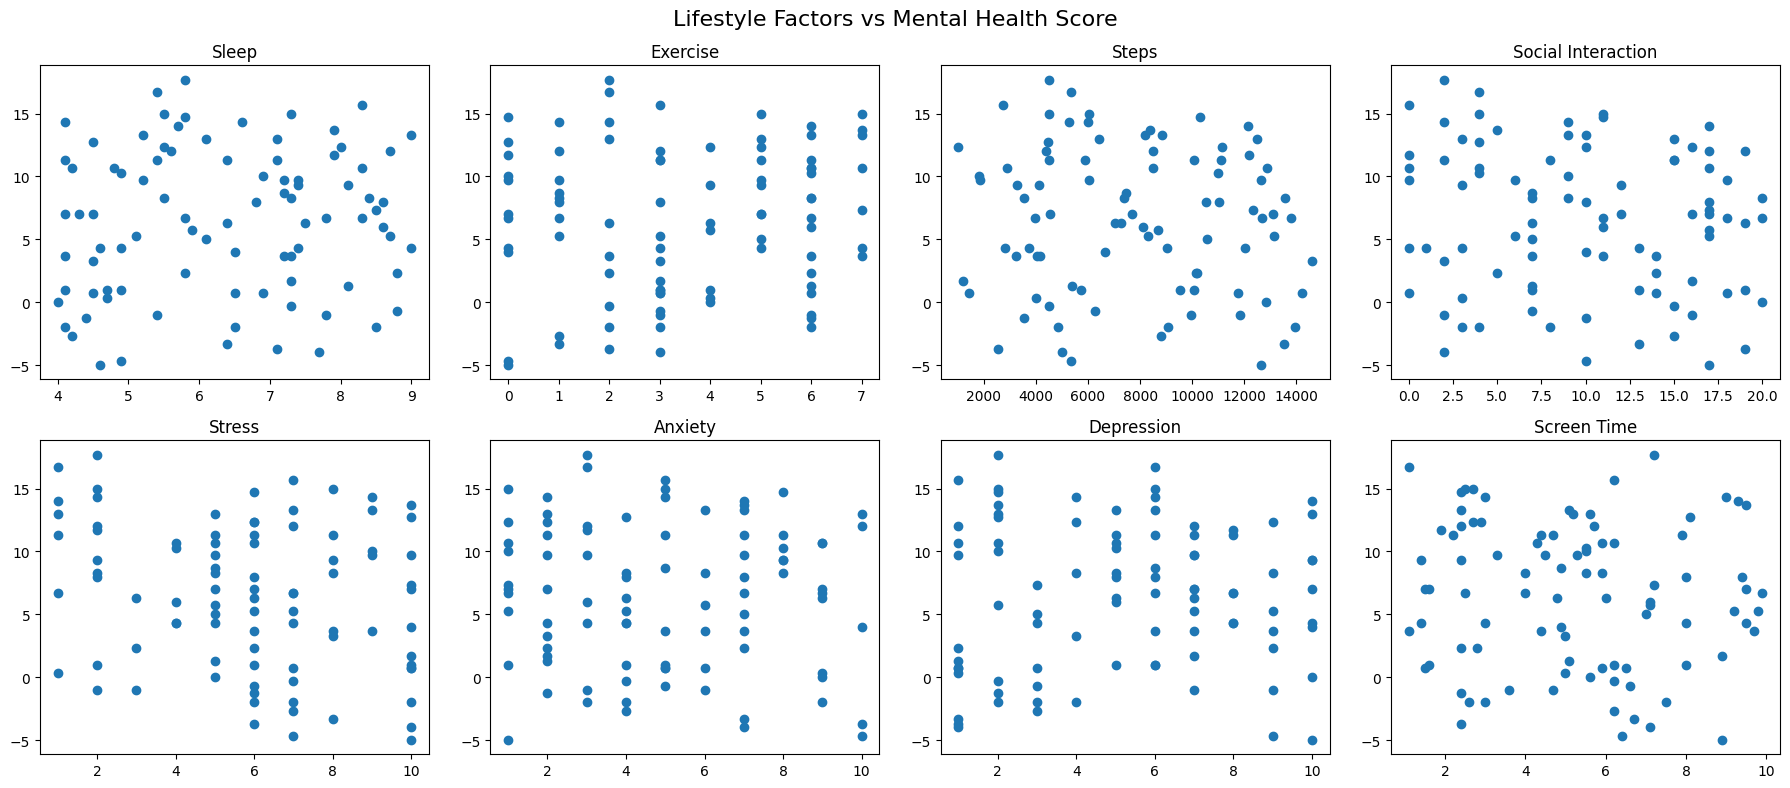

In [50]:
# Visualize the relationships between lifestyle factors and mental health score
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Positive factors
axes[0, 0].scatter(df["Sleep_Hours"], df["Mental_Health_Score"])
axes[0, 0].set_title("Sleep")

axes[0, 1].scatter(df["Exercise_Frequency"], df["Mental_Health_Score"])
axes[0, 1].set_title("Exercise")

axes[0, 2].scatter(df["Daily_Steps"], df["Mental_Health_Score"])
axes[0, 2].set_title("Steps")

axes[0, 3].scatter(df["Social_Interaction"], df["Mental_Health_Score"])
axes[0, 3].set_title("Social Interaction")

# Negative factors
axes[1, 0].scatter(df["Stress_Level"], df["Mental_Health_Score"])
axes[1, 0].set_title("Stress")

axes[1, 1].scatter(df["Anxiety_Level"], df["Mental_Health_Score"])
axes[1, 1].set_title("Anxiety")

axes[1, 2].scatter(df["Depression_Level"], df["Mental_Health_Score"])
axes[1, 2].set_title("Depression")

axes[1, 3].scatter(df["Screen_Time_Hours"], df["Mental_Health_Score"])
axes[1, 3].set_title("Screen Time")

# Improve layout
for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Lifestyle Factors vs Mental Health Score", fontsize=16)
plt.tight_layout()
plt.show()

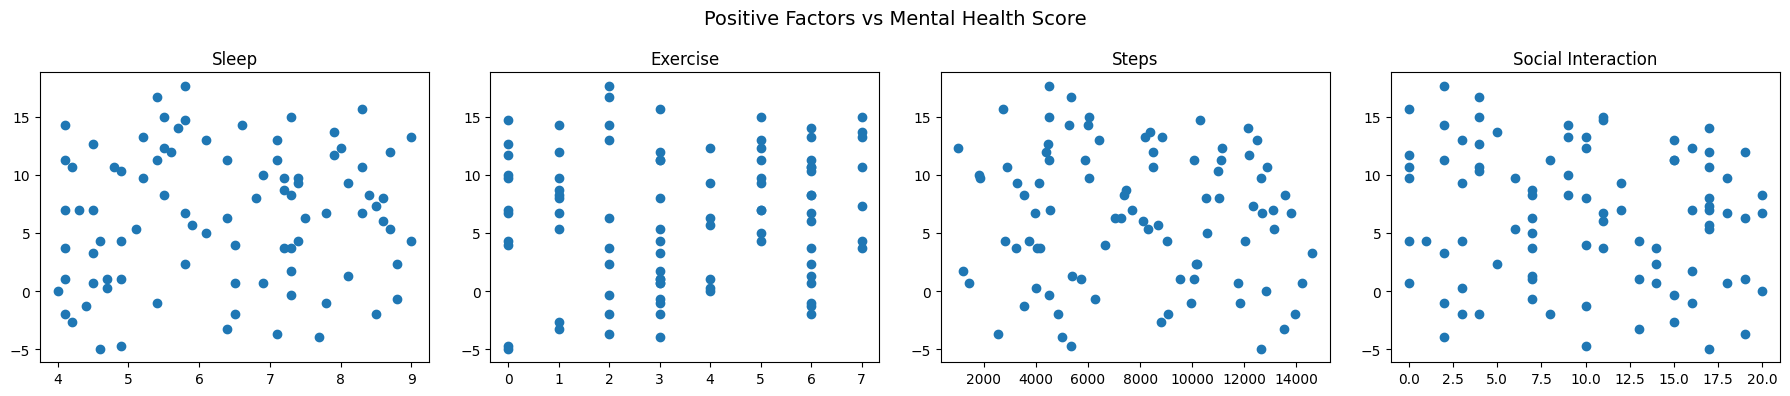

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].scatter(df["Sleep_Hours"], df["Mental_Health_Score"])
axes[0].set_title("Sleep")

axes[1].scatter(df["Exercise_Frequency"], df["Mental_Health_Score"])
axes[1].set_title("Exercise")

axes[2].scatter(df["Daily_Steps"], df["Mental_Health_Score"])
axes[2].set_title("Steps")

axes[3].scatter(df["Social_Interaction"], df["Mental_Health_Score"])
axes[3].set_title("Social Interaction")

fig.suptitle("Positive Factors vs Mental Health Score", fontsize=14)
plt.tight_layout()
plt.show()

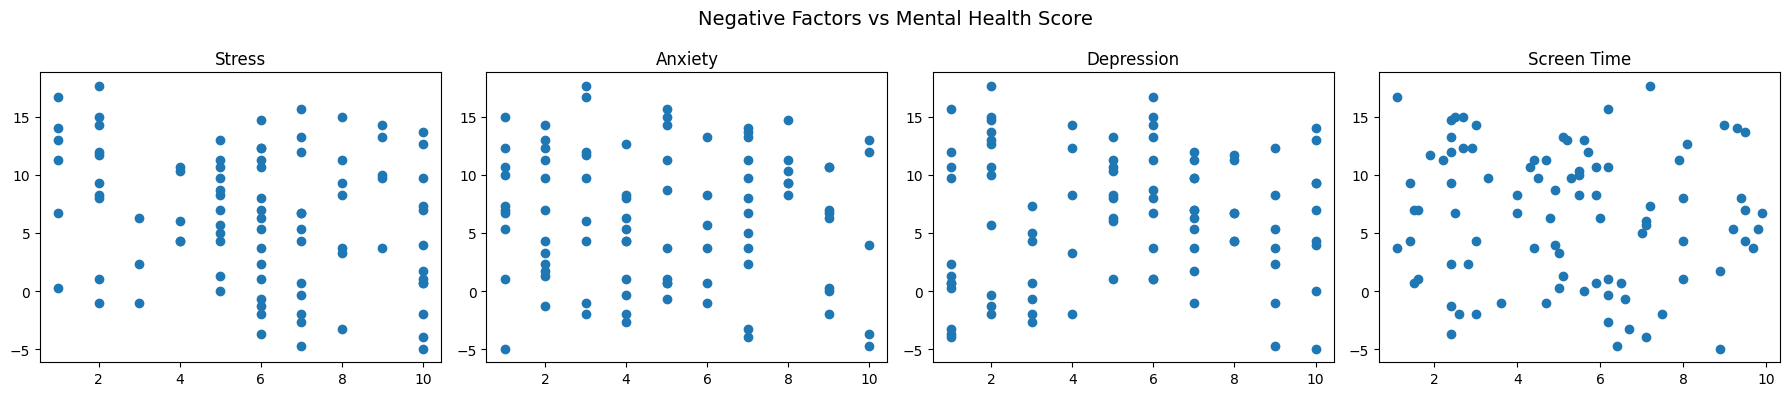

In [52]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].scatter(df["Stress_Level"], df["Mental_Health_Score"])
axes[0].set_title("Stress")

axes[1].scatter(df["Anxiety_Level"], df["Mental_Health_Score"])
axes[1].set_title("Anxiety")

axes[2].scatter(df["Depression_Level"], df["Mental_Health_Score"])
axes[2].set_title("Depression")

axes[3].scatter(df["Screen_Time_Hours"], df["Mental_Health_Score"])
axes[3].set_title("Screen Time")

fig.suptitle("Negative Factors vs Mental Health Score", fontsize=14)
plt.tight_layout()
plt.show()

Heatmap

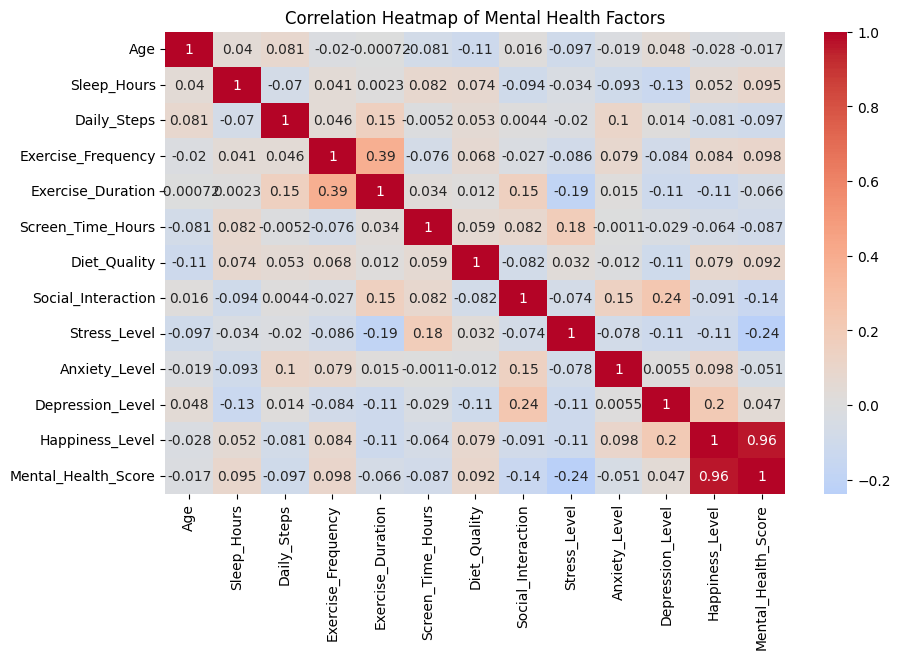

In [53]:

# Correlation heatmap of all numeric variables
plt.figure(figsize=(10, 6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Mental Health Factors")
plt.show()

Barchart

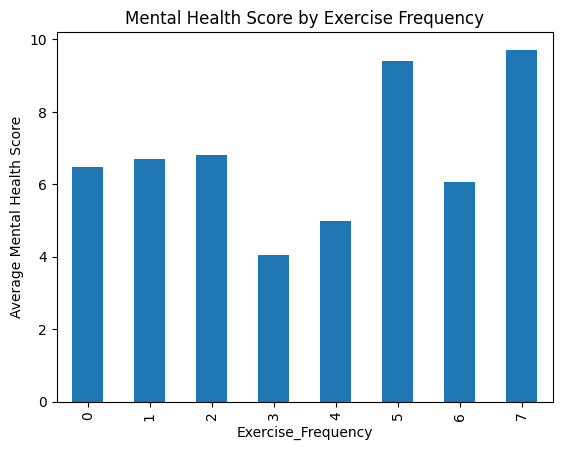

In [54]:
# Group by exercise frequency and calculate the average mental health score for each level
df.groupby("Exercise_Frequency")["Mental_Health_Score"].mean().plot(kind="bar")
plt.title("Mental Health Score by Exercise Frequency")
plt.ylabel("Average Mental Health Score")
plt.show()

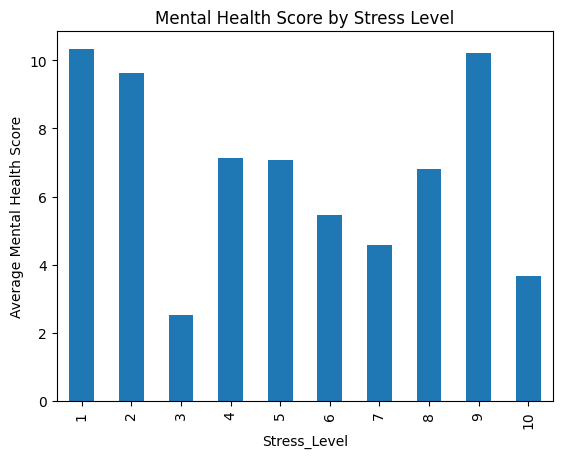

In [55]:
# Group by stress level and calculate the average mental health score for each level
df.groupby("Stress_Level")["Mental_Health_Score"].mean().plot(kind="bar")
plt.title("Mental Health Score by Stress Level")
plt.ylabel("Average Mental Health Score")
plt.show()

Linear Regression

In [56]:
# Prepare data for modeling
features = [
    "Sleep_Hours",
    "Daily_Steps",
    "Exercise_Frequency",
    "Exercise_Duration",
    "Diet_Quality",
    "Social_Interaction",
    "Screen_Time_Hours",
    "Stress_Level",
    "Anxiety_Level",
    "Depression_Level",
    "Happiness_Level"
]

X = df[features]
y = df["Mental_Health_Score"]

In [57]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
print("R^2 Score:", model.score(X_test, y_test))

R^2 Score: 0.9999657073952919


Depression_Level     -3.371693e-01
Anxiety_Level        -3.327790e-01
Stress_Level         -3.315600e-01
Diet_Quality         -2.608571e-03
Exercise_Frequency   -2.190956e-03
Screen_Time_Hours    -2.203279e-04
Daily_Steps          -5.310666e-07
Exercise_Duration     8.234443e-05
Sleep_Hours           4.133969e-04
Social_Interaction    1.145688e-03
Happiness_Level       2.000549e+00
dtype: float64


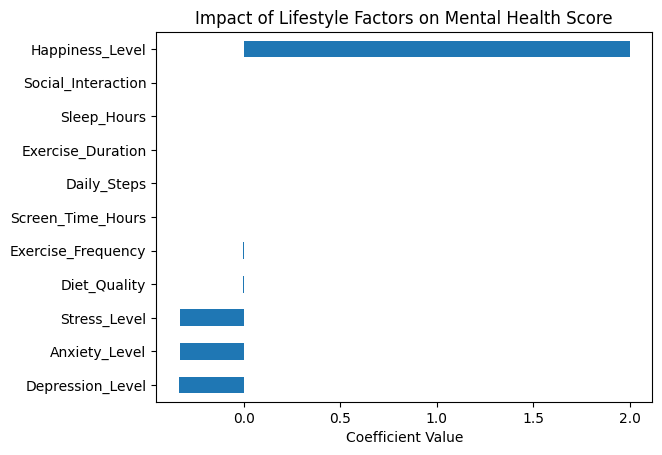

In [58]:
# Display the coefficients of the model
coefficients = pd.Series(model.coef_, index=features)
coefficients = coefficients.sort_values()
print(coefficients)

# Visualize the coefficients
coefficients.plot(kind="barh")
plt.title("Impact of Lifestyle Factors on Mental Health Score")
plt.xlabel("Coefficient Value")
plt.show()

Clustering

In [59]:
# Prepare data for clustering
cluster_features = [
    "Age",
    "Sleep_Hours",
    "Daily_Steps",
    "Exercise_Frequency",
    "Exercise_Duration",
    "Screen_Time_Hours",
    "Diet_Quality",
    "Social_Interaction",
    "Stress_Level",
    "Anxiety_Level",
    "Depression_Level",
    "Happiness_Level"
]

X_cluster = df[cluster_features]

In [60]:
# Scale the features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

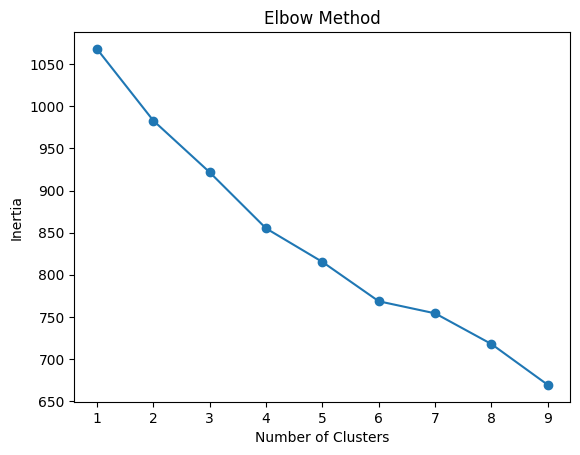

In [61]:
# Scale the features
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [74]:
# Perform K-means clustering
kmeans = KMeans(n_clusters=2,random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Display the average values of the features for each cluster
df.groupby("Cluster")[cluster_features].mean()

,Age,Sleep_Hours,Daily_Steps,Exercise_Frequency,Exercise_Duration,Screen_Time_Hours,Diet_Quality,Social_Interaction,Stress_Level,Anxiety_Level,Depression_Level,Happiness_Level
Cluster,,,,,,,,,,,,
0,53.451613,5.990323,8709.387097,3.161290,41.738710,4.100000,2.032258,11.580645,5.645161,5.354839,6.645161,5.741935
1,38.172414,6.562069,7286.862069,3.655172,45.115517,5.810345,3.672414,9.051724,6.051724,4.810345,4.482759,6.017241


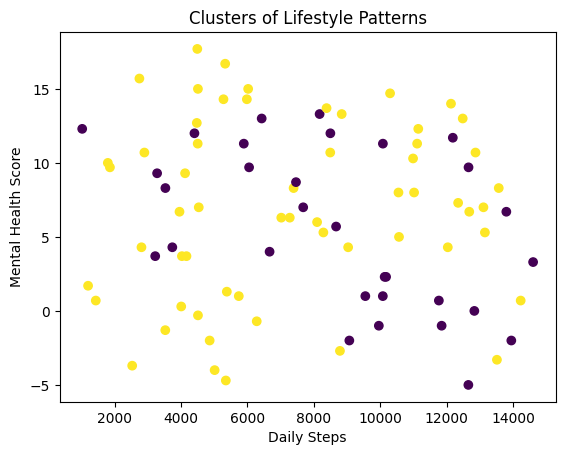

In [75]:
plt.scatter(
    df["Daily_Steps"],
    df["Mental_Health_Score"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Daily Steps")
plt.ylabel("Mental Health Score")
plt.title("Clusters of Lifestyle Patterns")
plt.show()

Decision Tree

In [64]:
# Categorize mental health scores
df["MH_Category"] = pd.cut(
    df["Mental_Health_Score"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

In [65]:
# Define the feature columns
features = [
    "Sleep_Hours",
    "Daily_Steps",
    "Exercise_Frequency",
    "Exercise_Duration",
    "Diet_Quality",
    "Social_Interaction",
    "Screen_Time_Hours",
    "Stress_Level",
    "Anxiety_Level",
    "Depression_Level",
    "Happiness_Level"
]

X = df[features]
y = df["MH_Category"]

In [73]:
# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train the decision tree classifier
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8888888888888888


Random Forest

In [67]:
# Define the feature columns
features = [
    "Sleep_Hours",
    "Daily_Steps",
    "Exercise_Frequency",
    "Exercise_Duration",
    "Diet_Quality",
    "Social_Interaction",
    "Screen_Time_Hours",
    "Stress_Level",
    "Anxiety_Level",
    "Depression_Level",
    "Happiness_Level"
]

X = df[features]
y = df["MH_Category"]

In [68]:
# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [69]:
# Train a random forest classifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Evaluate the model
print("Random Forest Accuracy:", rf.score(X_test, y_test))

Random Forest Accuracy: 0.8888888888888888


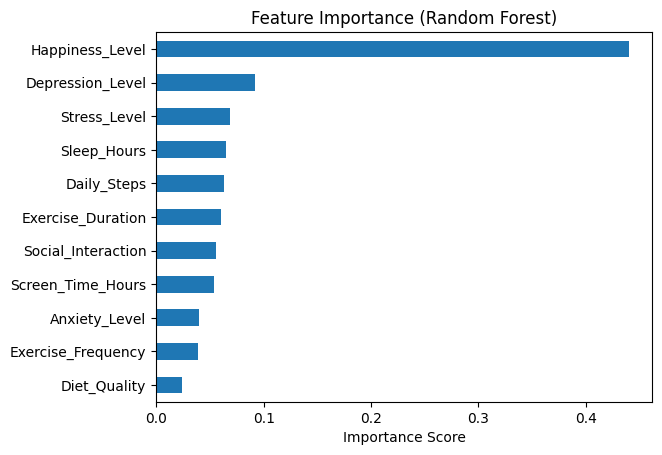

In [70]:
# Display feature importance
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values()

importances.plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

XGBoost

Stratified